# Student-t SuperTrend — Hypothesis Validation

**Core Innovation:** Adaptive EMA smoothing using Student-t distribution weighting.
Standard EMA uses fixed α = 2/(N+1). This variant modifies alpha per-bar:

$$\alpha_{\text{raw}} = \frac{\alpha_{\text{base}}}{1 + |r_t / \sigma_t|^{\nu}}$$

Large moves (outlier wicks) → α drops to floor → EMA ignores them. Normal moves → near-standard α.

## Hypotheses Under Test
| # | Hypothesis | Core Question |
|---|-----------|---------------|
| H1 | Direction flip filtered by alpha | Do t-SuperTrend flips on 'normal' bars (high α) predict better than flips on spikes (low α)? |
| H2 | Alpha collapse as MR trigger | When α crashes (outlier bar), does price revert within N bars? |
| H3 | t-SuperTrend as regime gate | Does t-ST direction improve existing MR/Momentum model returns? |
| H4 | Robust ATR for stop placement | Does t-ATR produce fewer stop-outs than standard ATR at equal distance? |

**Go/No-Go per hypothesis:** Forward return |r| > 0.03, win rate > 53%, positive expectancy, orthogonal to existing signals.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import time
from datetime import datetime, timezone
from scipy import stats as sp_stats
import warnings
warnings.filterwarnings('ignore')

from binance.um_futures import UMFutures
from libs.features.indicators.momentum.rsi import _compute_rsi_batch
from libs.features.indicators.volatility.atr import _compute_atr_batch
from libs.features.indicators.trend.ema import _compute_ema_batch

plt.style.use('dark_background')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

client = UMFutures()
print('Setup complete')

Setup complete


---
## 0. Data Fetch — Multi-TF OHLCV

In [2]:
# ── OHLCV fetch with pagination ────────────────────────────────────
_ALL_COLS = [
    'timestamp', 'open', 'high', 'low', 'close', 'volume', 'close_time',
    'quote_volume', 'trades', 'taker_buy_base', 'taker_buy_quote', 'ignore'
]

def fetch_ohlcv(symbol: str, interval: str, start_date: str, end_date: str) -> pd.DataFrame:
    """Fetch OHLCV with auto-pagination."""
    start_ms = int(datetime.strptime(start_date, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1000)
    end_ms = int(datetime.strptime(end_date, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1000)
    all_rows = []
    cursor = start_ms
    while cursor < end_ms:
        raw = client.klines(symbol, interval, startTime=cursor, endTime=end_ms, limit=1500)
        if not raw:
            break
        all_rows.extend(raw)
        cursor = int(raw[-1][6]) + 1  # close_time + 1
        if len(raw) < 1500:
            break
        time.sleep(0.15)
    df = pd.DataFrame(all_rows, columns=_ALL_COLS)
    for c in ['open','high','low','close','volume','taker_buy_base','taker_buy_quote']:
        df[c] = df[c].astype(float)
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True)
    df = df.drop_duplicates('timestamp').sort_values('timestamp').reset_index(drop=True)
    print(f'{symbol} {interval}: {len(df)} bars  [{df.timestamp.iloc[0]} → {df.timestamp.iloc[-1]}]')
    return df

# Fetch data: 6 months across 2 timeframes
SYMBOLS = ['BTCUSDT', 'ETHUSDT']
START, END = '2025-12-01', '2026-05-31'

data = {}
for sym in SYMBOLS:
    data[sym] = {}
    for tf in ['1h', '4h']:
        data[sym][tf] = fetch_ohlcv(sym, tf, START, END)

print(f'\nTotal datasets: {sum(len(data[s]) for s in data)}')

BTCUSDT 1h: 4345 bars  [2025-12-01 00:00:00+00:00 → 2026-05-31 00:00:00+00:00]
BTCUSDT 4h: 1087 bars  [2025-12-01 00:00:00+00:00 → 2026-05-31 00:00:00+00:00]
ETHUSDT 1h: 4345 bars  [2025-12-01 00:00:00+00:00 → 2026-05-31 00:00:00+00:00]
ETHUSDT 4h: 1087 bars  [2025-12-01 00:00:00+00:00 → 2026-05-31 00:00:00+00:00]

Total datasets: 4


---
## 1. Implement Standard SuperTrend vs Student-t SuperTrend

In [3]:
# ── Standard SuperTrend (baseline) ──────────────────────────────────
def standard_supertrend(df: pd.DataFrame, atr_len: int = 10, atr_mult: float = 3.0) -> pd.DataFrame:
    """Standard SuperTrend: EMA-ATR bands with direction flip."""
    h, l, c = df['high'].values, df['low'].values, df['close'].values
    n = len(c)

    # True Range
    tr = np.empty(n)
    tr[0] = h[0] - l[0]
    for i in range(1, n):
        tr[i] = max(h[i] - l[i], abs(h[i] - c[i-1]), abs(l[i] - c[i-1]))

    # Standard EMA-ATR
    alpha_atr = 2.0 / (atr_len + 1)
    atr = np.empty(n)
    atr[0] = tr[0]
    for i in range(1, n):
        atr[i] = alpha_atr * tr[i] + (1 - alpha_atr) * atr[i-1]

    # SuperTrend
    typical = (h + l + c) / 3.0
    upper = typical + atr_mult * atr
    lower = typical - atr_mult * atr

    direction = np.ones(n, dtype=bool)  # True = uptrend
    st = np.empty(n)
    st[0] = lower[0] if c[0] > typical[0] else upper[0]
    direction[0] = c[0] > typical[0]

    for i in range(1, n):
        if c[i] > st[i-1]:
            direction[i] = True
            st[i] = max(lower[i], st[i-1])
        elif c[i] < st[i-1]:
            direction[i] = False
            st[i] = min(upper[i], st[i-1])
        else:
            direction[i] = direction[i-1]
            st[i] = max(lower[i], st[i-1]) if direction[i] else min(upper[i], st[i-1])

    return pd.DataFrame({
        'st_standard': st,
        'dir_standard': direction,
        'atr_standard': atr,
    }, index=df.index)

print('Standard SuperTrend implemented')

Standard SuperTrend implemented


In [4]:
# ── Student-t SuperTrend (novel variant) ────────────────────────────
def student_t_supertrend(
    df: pd.DataFrame,
    atr_len: int = 10,
    atr_mult: float = 3.0,
    span: int = 14,
    nu: float = 5.0,
    vol_window: int = 30,
    gamma: float = 1.0,
    alpha_floor: float = 0.02,
    vol_high_pct: float = 85.0,
    vol_low_pct: float = 15.0,
) -> pd.DataFrame:
    """
    Student-t adaptive SuperTrend.
    Returns: st, direction, t_ema, adaptive_alpha, t_atr, vol_regime, dynamic_nu
    """
    h, l, c = df['high'].values, df['low'].values, df['close'].values
    n = len(c)
    base_alpha = 2.0 / (span + 1)

    # Returns and rolling vol
    returns = np.zeros(n)
    returns[1:] = (c[1:] - c[:-1]) / c[:-1]

    sigma = pd.Series(returns).rolling(vol_window, min_periods=1).std().values
    sigma = np.maximum(sigma, 1e-10)

    # Volatility regime (percentile-based)
    sigma_series = pd.Series(sigma)
    vol_pct_high = sigma_series.rolling(vol_window, min_periods=1).quantile(vol_high_pct / 100).values
    vol_pct_low = sigma_series.rolling(vol_window, min_periods=1).quantile(vol_low_pct / 100).values

    vol_regime = np.full(n, 1, dtype=int)  # 0=LOW, 1=NORMAL, 2=HIGH
    vol_regime[sigma > vol_pct_high] = 2
    vol_regime[sigma < vol_pct_low] = 0

    # Dynamic nu
    dyn_nu = np.full(n, nu)
    dyn_nu[vol_regime == 2] = nu * 0.7   # HIGH vol → heavier tails
    dyn_nu[vol_regime == 0] = nu * 1.3   # LOW vol → closer to Gaussian

    # ── Adaptive alpha (Student-t weighting) ──
    z = np.abs(returns / sigma)
    alpha_raw = base_alpha / (1.0 + np.power(z, dyn_nu))
    adaptive_alpha = np.clip(gamma * alpha_raw, alpha_floor, 0.99)

    # ── t-EMA ──
    t_ema = np.empty(n)
    t_ema[0] = c[0]
    for i in range(1, n):
        t_ema[i] = adaptive_alpha[i] * c[i] + (1 - adaptive_alpha[i]) * t_ema[i-1]

    # ── True Range ──
    tr = np.empty(n)
    tr[0] = max(h[0] - l[0], 1e-8)
    for i in range(1, n):
        tr[i] = max(h[i] - l[i], abs(h[i] - c[i-1]), abs(l[i] - c[i-1]), 1e-8)

    # ── Student-t ATR (adaptive smoothing on TR) ──
    base_alpha_atr = 2.0 / (atr_len + 1)
    tr_ret = np.zeros(n)
    tr_ret[1:] = np.clip((tr[1:] - tr[:-1]) / np.maximum(tr[:-1], 1e-8), -2, 2)
    sigma_tr = pd.Series(tr_ret).rolling(vol_window, min_periods=1).std().values
    sigma_tr = np.maximum(sigma_tr, 1e-6)
    z_tr = np.abs(tr_ret / sigma_tr)
    alpha_raw_atr = base_alpha_atr / (1.0 + np.power(z_tr, np.maximum(dyn_nu, 0.1)))
    alpha_atr = np.clip(gamma * alpha_raw_atr, alpha_floor, 0.99)

    t_atr = np.empty(n)
    t_atr[0] = tr[0]
    for i in range(1, n):
        t_atr[i] = max(alpha_atr[i] * tr[i] + (1 - alpha_atr[i]) * t_atr[i-1], c[i] * 0.0001)

    # ── Student-t smoothed typical price ──
    typical = (h + l + c) / 3.0
    typ_ret = np.zeros(n)
    typ_ret[1:] = np.clip((typical[1:] - typical[:-1]) / np.maximum(np.abs(typical[:-1]), 1e-8), -0.5, 0.5)
    sigma_typ = pd.Series(typ_ret).rolling(vol_window, min_periods=1).std().values
    sigma_typ = np.maximum(sigma_typ, 1e-6)
    z_typ = np.abs(typ_ret / sigma_typ)
    alpha_raw_typ = base_alpha / (1.0 + np.power(z_typ, np.maximum(dyn_nu, 0.1)))
    alpha_typ = np.clip(gamma * alpha_raw_typ, alpha_floor, 0.99)

    stu_typical = np.empty(n)
    stu_typical[0] = typical[0]
    for i in range(1, n):
        stu_typical[i] = alpha_typ[i] * typical[i] + (1 - alpha_typ[i]) * stu_typical[i-1]

    # ── Volatility-adjusted multiplier ──
    dyn_mult = np.full(n, atr_mult)
    dyn_mult[vol_regime == 2] = atr_mult * 1.15
    dyn_mult[vol_regime == 0] = atr_mult * 0.9

    # ── Volatility weight from alpha deviation ──
    vol_weight = np.clip(1.0 + (adaptive_alpha - base_alpha), 0.5, 2.0)

    # ── SuperTrend bands ──
    upper = stu_typical + dyn_mult * t_atr * vol_weight
    lower = stu_typical - dyn_mult * t_atr * vol_weight

    # ── Direction and SuperTrend line ──
    direction = np.ones(n, dtype=bool)
    st = np.empty(n)
    direction[0] = c[0] > stu_typical[0]
    st[0] = lower[0] if direction[0] else upper[0]

    for i in range(1, n):
        if c[i] > st[i-1]:
            direction[i] = True
            st[i] = max(lower[i], st[i-1])
        elif c[i] < st[i-1]:
            direction[i] = False
            st[i] = min(upper[i], st[i-1])
        else:
            direction[i] = direction[i-1]
            st[i] = max(lower[i], st[i-1]) if direction[i] else min(upper[i], st[i-1])

    # Clamp ST within 20% of price (safety)
    st = np.clip(st, c * 0.8, c * 1.2)

    return pd.DataFrame({
        'st_student': st,
        'dir_student': direction,
        'atr_student': t_atr,
        't_ema': t_ema,
        'adaptive_alpha': adaptive_alpha,
        'vol_regime': vol_regime,   # 0=LOW, 1=NORMAL, 2=HIGH
        'dyn_nu': dyn_nu,
    }, index=df.index)

print('Student-t SuperTrend implemented')

Student-t SuperTrend implemented


In [5]:
# ── Compute both SuperTrends for all datasets ───────────────────────
results = {}
for sym in SYMBOLS:
    results[sym] = {}
    for tf in ['1h', '4h']:
        df = data[sym][tf].copy()
        std_st = standard_supertrend(df)
        stu_st = student_t_supertrend(df)
        combined = pd.concat([df, std_st, stu_st], axis=1)

        # Forward returns for hypothesis testing
        for horizon in [1, 3, 6, 12, 24]:
            combined[f'fwd_ret_{horizon}'] = combined['close'].pct_change(horizon).shift(-horizon)

        # Direction flips
        combined['flip_standard'] = combined['dir_standard'] != combined['dir_standard'].shift(1)
        combined['flip_student'] = combined['dir_student'] != combined['dir_student'].shift(1)

        # Drop warmup
        combined = combined.iloc[50:].copy()
        results[sym][tf] = combined

        # Stats
        n_flips_std = combined['flip_standard'].sum()
        n_flips_stu = combined['flip_student'].sum()
        print(f'{sym} {tf}: {len(combined)} bars | Flips: standard={n_flips_std}, student-t={n_flips_stu} ({n_flips_stu/max(n_flips_std,1):.2f}x)')

BTCUSDT 1h: 4295 bars | Flips: standard=257, student-t=241 (0.94x)
BTCUSDT 4h: 1037 bars | Flips: standard=72, student-t=52 (0.72x)
ETHUSDT 1h: 4295 bars | Flips: standard=237, student-t=181 (0.76x)
ETHUSDT 4h: 1037 bars | Flips: standard=67, student-t=60 (0.90x)


---
## H1: Direction Flip Quality — Alpha-Filtered Flips

**Hypothesis:** t-SuperTrend flips that occur when adaptive alpha is *high* (normal bar, not a spike) should predict better than flips on *low* alpha bars (spike/outlier). Standard SuperTrend has no such filter.

In [6]:
# ── H1: Compare flip quality by alpha regime ──────────────────────
print('=' * 80)
print('H1: Direction Flip Quality — Alpha-Filtered vs Unfiltered')
print('=' * 80)

for sym in SYMBOLS:
    for tf in ['1h', '4h']:
        df = results[sym][tf]
        base_alpha = 2.0 / (14 + 1)  # span=14
        alpha_median = df['adaptive_alpha'].median()

        # Classify flips by alpha level at flip bar
        flips_stu = df[df['flip_student']].copy()
        flips_std = df[df['flip_standard']].copy()

        # Split student-t flips: high alpha (normal move) vs low alpha (outlier)
        flips_high_alpha = flips_stu[flips_stu['adaptive_alpha'] > alpha_median]
        flips_low_alpha = flips_stu[flips_stu['adaptive_alpha'] <= alpha_median]

        print(f'\n--- {sym} {tf} ---')
        print(f'Total flips: standard={len(flips_std)}, student-t={len(flips_stu)}')
        print(f'Student-t flips: high-α={len(flips_high_alpha)}, low-α={len(flips_low_alpha)}')
        print(f'Alpha stats: median={alpha_median:.4f}, base={base_alpha:.4f}')

        # Forward returns after flip, conditioned on new direction
        for label, subset in [('Std-All', flips_std), ('Stu-HighAlpha', flips_high_alpha), ('Stu-LowAlpha', flips_low_alpha)]:
            if len(subset) < 5:
                print(f'  {label}: too few flips ({len(subset)})')
                continue

            # Use the direction column relevant to this subset
            dir_col = 'dir_standard' if 'Std' in label else 'dir_student'
            is_bull_flip = subset[dir_col].values  # True = flipped to bullish

            # Signed return: positive if direction was correct
            for h in [1, 3, 6, 12]:
                fwd = subset[f'fwd_ret_{h}'].dropna()
                dir_at_flip = subset.loc[fwd.index, dir_col].values
                signed = np.where(dir_at_flip, fwd.values, -fwd.values)  # bull flip → want positive ret

                wr = (signed > 0).mean() * 100
                mean_ret = signed.mean() * 100
                n_trades = len(signed)
                print(f'  {label} | h={h:2d}: WR={wr:.1f}%  mean={mean_ret:+.3f}%  n={n_trades}')

H1: Direction Flip Quality — Alpha-Filtered vs Unfiltered

--- BTCUSDT 1h ---
Total flips: standard=257, student-t=241
Student-t flips: high-α=37, low-α=204
Alpha stats: median=0.1278, base=0.1333
  Std-All | h= 1: WR=47.5%  mean=+0.038%  n=257
  Std-All | h= 3: WR=49.8%  mean=+0.000%  n=257
  Std-All | h= 6: WR=49.8%  mean=-0.044%  n=257
  Std-All | h=12: WR=48.6%  mean=-0.082%  n=257
  Stu-HighAlpha | h= 1: WR=43.2%  mean=-0.020%  n=37
  Stu-HighAlpha | h= 3: WR=56.8%  mean=+0.078%  n=37
  Stu-HighAlpha | h= 6: WR=54.1%  mean=+0.445%  n=37
  Stu-HighAlpha | h=12: WR=62.2%  mean=+0.454%  n=37
  Stu-LowAlpha | h= 1: WR=43.1%  mean=-0.032%  n=204
  Stu-LowAlpha | h= 3: WR=48.0%  mean=-0.075%  n=204
  Stu-LowAlpha | h= 6: WR=40.2%  mean=-0.178%  n=204
  Stu-LowAlpha | h=12: WR=43.1%  mean=-0.198%  n=204

--- BTCUSDT 4h ---
Total flips: standard=72, student-t=52
Student-t flips: high-α=9, low-α=43
Alpha stats: median=0.1275, base=0.1333
  Std-All | h= 1: WR=43.1%  mean=-0.012%  n=72
  Std

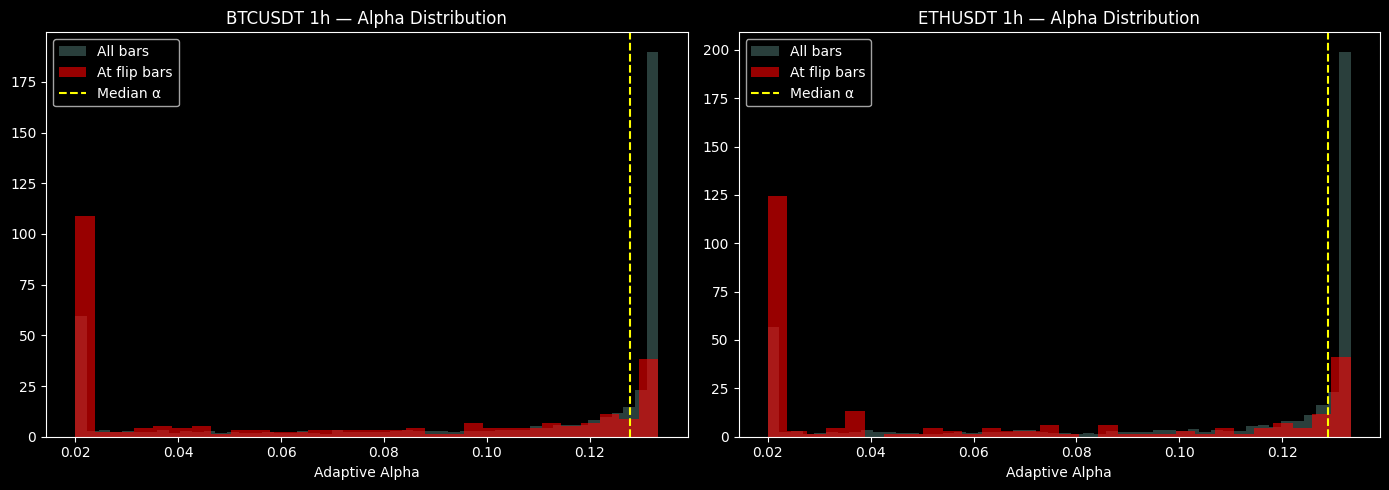

In [7]:
# ── H1 Visual: Alpha distribution at flip points ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, sym in enumerate(SYMBOLS):
    df = results[sym]['1h']
    ax = axes[idx]

    # All bars alpha
    ax.hist(df['adaptive_alpha'], bins=50, alpha=0.3, label='All bars', density=True)
    # Alpha at flip points only
    flip_alphas = df.loc[df['flip_student'], 'adaptive_alpha']
    if len(flip_alphas) > 3:
        ax.hist(flip_alphas, bins=30, alpha=0.6, label='At flip bars', density=True, color='red')
    ax.axvline(df['adaptive_alpha'].median(), color='yellow', linestyle='--', label='Median α')
    ax.set_title(f'{sym} 1h — Alpha Distribution')
    ax.set_xlabel('Adaptive Alpha')
    ax.legend()

plt.tight_layout()
plt.show()

---
## H2: Alpha Collapse as Mean-Reversion Trigger

**Hypothesis:** When adaptive alpha crashes to near-floor (outlier bar detected by the Student-t mechanism), price reverts within N bars. This is the inverse of trend-following — it's an outlier-detection MR signal.

In [10]:
# ── H2: Alpha collapse → mean reversion ──────────────────────────
print('=' * 80)
print('H2: Alpha Collapse as Mean-Reversion Trigger')
print('=' * 80)

for sym in SYMBOLS:
    for tf in ['1h', '4h']:
        df = results[sym][tf].reset_index(drop=True)

        # Define alpha collapse: bottom 10th percentile of alpha
        alpha_10 = df['adaptive_alpha'].quantile(0.10)
        alpha_5 = df['adaptive_alpha'].quantile(0.05)

        for threshold_label, threshold in [('p10', alpha_10), ('p5', alpha_5)]:
            collapse_mask = df['adaptive_alpha'] <= threshold
            collapse_bars = df[collapse_mask]
            n_events = len(collapse_bars)

            if n_events < 5:
                print(f'\n{sym} {tf} α≤{threshold_label}: too few events ({n_events})')
                continue

            # Bar return at each collapse event
            c_vals = df['close'].values
            bar_return = np.zeros(n_events)
            for j, idx in enumerate(collapse_bars.index):
                if idx > 0:
                    bar_return[j] = (c_vals[idx] - c_vals[idx - 1]) / c_vals[idx - 1]

            print(f'\n--- {sym} {tf} | α ≤ {threshold_label} (threshold={threshold:.4f}) | n={n_events} ---')
            print(f'Alpha at events: mean={collapse_bars["adaptive_alpha"].mean():.4f}')

            # MR test: does price reverse the outlier move?
            for h in [1, 3, 6, 12, 24]:
                fwd = collapse_bars[f'fwd_ret_{h}'].dropna()
                if len(fwd) < 3:
                    continue
                # Match bar_return to fwd indices
                fwd_positions = [list(collapse_bars.index).index(i) for i in fwd.index]
                spike_dir = bar_return[fwd_positions]
                # MR return: opposite of spike direction
                mr_return = np.where(spike_dir > 0, -fwd.values, fwd.values)

                wr = (mr_return > 0).mean() * 100
                mean_ret = mr_return.mean() * 100
                raw_mean = fwd.mean() * 100
                print(f'  h={h:2d}: MR_WR={wr:.1f}%  MR_mean={mean_ret:+.3f}%  raw_fwd={raw_mean:+.3f}%  n={len(fwd)}')

H2: Alpha Collapse as Mean-Reversion Trigger

--- BTCUSDT 1h | α ≤ p10 (threshold=0.0200) | n=542 ---
Alpha at events: mean=0.0200
  h= 1: MR_WR=49.8%  MR_mean=-0.034%  raw_fwd=-0.013%  n=542
  h= 3: MR_WR=49.1%  MR_mean=-0.072%  raw_fwd=-0.041%  n=542
  h= 6: MR_WR=51.8%  MR_mean=-0.028%  raw_fwd=+0.026%  n=542
  h=12: MR_WR=50.9%  MR_mean=-0.100%  raw_fwd=+0.024%  n=542
  h=24: MR_WR=49.1%  MR_mean=-0.086%  raw_fwd=+0.094%  n=542

--- BTCUSDT 1h | α ≤ p5 (threshold=0.0200) | n=542 ---
Alpha at events: mean=0.0200
  h= 1: MR_WR=49.8%  MR_mean=-0.034%  raw_fwd=-0.013%  n=542
  h= 3: MR_WR=49.1%  MR_mean=-0.072%  raw_fwd=-0.041%  n=542
  h= 6: MR_WR=51.8%  MR_mean=-0.028%  raw_fwd=+0.026%  n=542
  h=12: MR_WR=50.9%  MR_mean=-0.100%  raw_fwd=+0.024%  n=542
  h=24: MR_WR=49.1%  MR_mean=-0.086%  raw_fwd=+0.094%  n=542

--- BTCUSDT 4h | α ≤ p10 (threshold=0.0200) | n=139 ---
Alpha at events: mean=0.0200
  h= 1: MR_WR=53.2%  MR_mean=-0.058%  raw_fwd=+0.079%  n=139
  h= 3: MR_WR=52.5%  MR_mea

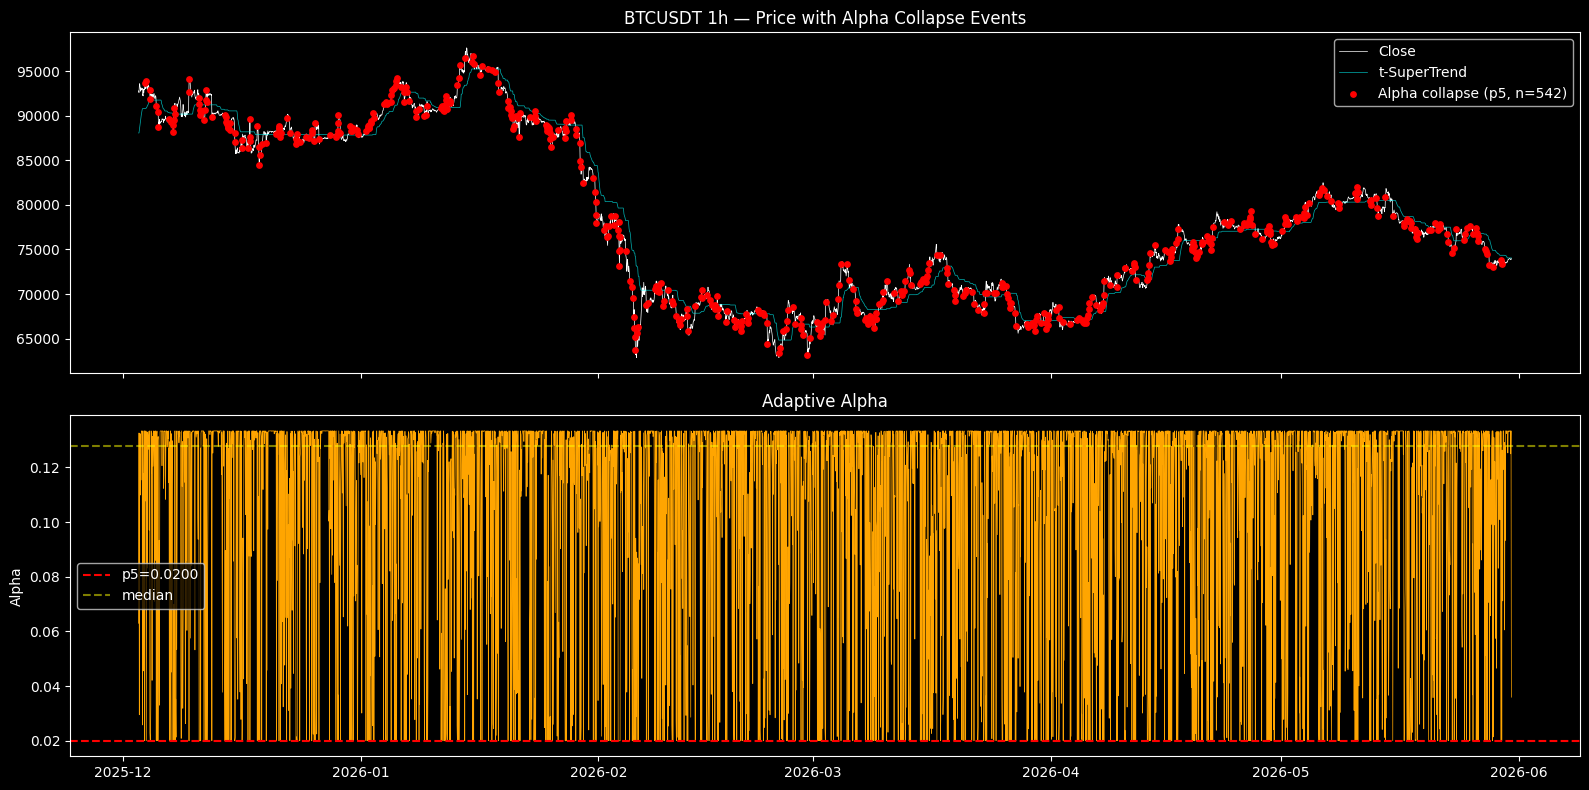

In [11]:
# ── H2 Visual: Alpha time series with collapse events ────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
sym, tf = 'BTCUSDT', '1h'
df = results[sym][tf]

# Price
axes[0].plot(df['timestamp'], df['close'], color='white', linewidth=0.5, label='Close')
axes[0].plot(df['timestamp'], df['st_student'], color='cyan', linewidth=0.5, alpha=0.7, label='t-SuperTrend')
alpha_5 = df['adaptive_alpha'].quantile(0.05)
collapse = df[df['adaptive_alpha'] <= alpha_5]
axes[0].scatter(collapse['timestamp'], collapse['close'], color='red', s=15, zorder=5, label=f'Alpha collapse (p5, n={len(collapse)})')
axes[0].set_title(f'{sym} {tf} — Price with Alpha Collapse Events')
axes[0].legend()

# Alpha
axes[1].plot(df['timestamp'], df['adaptive_alpha'], color='orange', linewidth=0.5)
axes[1].axhline(alpha_5, color='red', linestyle='--', label=f'p5={alpha_5:.4f}')
axes[1].axhline(df['adaptive_alpha'].median(), color='yellow', linestyle='--', alpha=0.5, label=f'median')
axes[1].set_title('Adaptive Alpha')
axes[1].set_ylabel('Alpha')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## H3: t-SuperTrend as Regime Gate for Existing Models

**Hypothesis:** Using t-SuperTrend direction to gate existing model signals improves returns:
- RSI MR signals only when t-ST says non-trending (dir flat or recent flip)
- Momentum signals only when t-ST confirms trend direction

Compare: ungated model returns vs t-ST-gated vs standard-ST-gated.

In [12]:
# ── H3: Regime gating with RSI signals ──────────────────────────
print('=' * 80)
print('H3: t-SuperTrend as Regime Gate for RSI Mean-Reversion')
print('=' * 80)

for sym in SYMBOLS:
    for tf in ['1h', '4h']:
        df = results[sym][tf].copy()

        # Compute RSI
        c = df['close'].values.astype(np.float64)
        rsi = np.full(len(c), np.nan)
        rsi_out = _compute_rsi_batch(c, 14)
        rsi[:len(rsi_out)] = rsi_out
        df['rsi'] = rsi

        # RSI MR signals: oversold (<30) → long, overbought (>70) → short
        df['rsi_long'] = df['rsi'] < 30
        df['rsi_short'] = df['rsi'] > 70

        # Bars where t-ST is in non-trend (recently flipped or direction choppy)
        # Proxy: bars since last flip < N (recent regime change = uncertain)
        flip_idx = df.index[df['flip_student']]
        bars_since_flip = pd.Series(np.nan, index=df.index)
        for fi in flip_idx:
            mask = df.index >= fi
            bars_since_flip[mask] = np.minimum(
                bars_since_flip[mask].fillna(9999),
                (df.index[mask] - fi)
            )
        bars_since_flip = bars_since_flip.fillna(9999).astype(int)

        # Gate: t-ST says non-trending (bars_since_flip < 5 = just flipped, uncertain)
        non_trending_gate = bars_since_flip < 5

        # Also: standard ST gate for comparison
        flip_idx_std = df.index[df['flip_standard']]
        bars_since_flip_std = pd.Series(np.nan, index=df.index)
        for fi in flip_idx_std:
            mask = df.index >= fi
            bars_since_flip_std[mask] = np.minimum(
                bars_since_flip_std[mask].fillna(9999),
                (df.index[mask] - fi)
            )
        bars_since_flip_std = bars_since_flip_std.fillna(9999).astype(int)
        non_trending_gate_std = bars_since_flip_std < 5

        print(f'\n--- {sym} {tf} ---')
        print(f'RSI signals: long={df["rsi_long"].sum()}, short={df["rsi_short"].sum()}')

        # Compare: ungated vs gated
        for label, long_mask, short_mask in [
            ('RSI-Ungated', df['rsi_long'], df['rsi_short']),
            ('RSI+tST-gate', df['rsi_long'] & ~df['dir_student'],   # RSI long when ST bearish (MR)
                              df['rsi_short'] & df['dir_student']),  # RSI short when ST bullish
            ('RSI+stdST-gate', df['rsi_long'] & ~df['dir_standard'],
                               df['rsi_short'] & df['dir_standard']),
        ]:
            for h in [1, 3, 6, 12]:
                # Long signals
                long_fwd = df.loc[long_mask, f'fwd_ret_{h}'].dropna()
                # Short signals (negate return)
                short_fwd = -df.loc[short_mask, f'fwd_ret_{h}'].dropna()
                all_fwd = pd.concat([long_fwd, short_fwd])

                if len(all_fwd) < 3:
                    continue
                wr = (all_fwd > 0).mean() * 100
                mean_ret = all_fwd.mean() * 100
                print(f'  {label:20s} h={h:2d}: WR={wr:.1f}%  mean={mean_ret:+.3f}%  n={len(all_fwd)}')

H3: t-SuperTrend as Regime Gate for RSI Mean-Reversion

--- BTCUSDT 1h ---
RSI signals: long=277, short=184
  RSI-Ungated          h= 1: WR=56.6%  mean=+0.006%  n=461
  RSI-Ungated          h= 3: WR=58.4%  mean=+0.021%  n=461
  RSI-Ungated          h= 6: WR=55.5%  mean=+0.039%  n=461
  RSI-Ungated          h=12: WR=55.7%  mean=+0.083%  n=461
  RSI+tST-gate         h= 1: WR=56.6%  mean=+0.006%  n=461
  RSI+tST-gate         h= 3: WR=58.4%  mean=+0.021%  n=461
  RSI+tST-gate         h= 6: WR=55.5%  mean=+0.039%  n=461
  RSI+tST-gate         h=12: WR=55.7%  mean=+0.083%  n=461
  RSI+stdST-gate       h= 1: WR=56.6%  mean=+0.006%  n=461
  RSI+stdST-gate       h= 3: WR=58.4%  mean=+0.021%  n=461
  RSI+stdST-gate       h= 6: WR=55.5%  mean=+0.039%  n=461
  RSI+stdST-gate       h=12: WR=55.7%  mean=+0.083%  n=461

--- BTCUSDT 4h ---
RSI signals: long=53, short=40
  RSI-Ungated          h= 1: WR=59.1%  mean=-0.003%  n=93
  RSI-Ungated          h= 3: WR=62.4%  mean=+0.028%  n=93
  RSI-Ungated    

In [13]:
# ── H3b: Momentum trend-following gated by t-ST ──────────────────
print('=' * 80)
print('H3b: t-SuperTrend as Regime Gate for Momentum (Trend-Following)')
print('=' * 80)

for sym in SYMBOLS:
    for tf in ['1h', '4h']:
        df = results[sym][tf].copy()

        # Simple momentum: 20-bar ROC
        df['roc_20'] = df['close'].pct_change(20)
        roc_thresh = df['roc_20'].rolling(100, min_periods=20).std() * 0.5

        df['mom_long'] = df['roc_20'] > roc_thresh
        df['mom_short'] = df['roc_20'] < -roc_thresh

        print(f'\n--- {sym} {tf} ---')
        print(f'Momentum signals: long={df["mom_long"].sum()}, short={df["mom_short"].sum()}')

        for label, long_mask, short_mask in [
            ('Mom-Ungated', df['mom_long'], df['mom_short']),
            ('Mom+tST-confirm', df['mom_long'] & df['dir_student'],    # mom long + ST bullish
                                df['mom_short'] & ~df['dir_student']),  # mom short + ST bearish
            ('Mom+stdST-confirm', df['mom_long'] & df['dir_standard'],
                                  df['mom_short'] & ~df['dir_standard']),
        ]:
            for h in [1, 3, 6, 12]:
                long_fwd = df.loc[long_mask, f'fwd_ret_{h}'].dropna()
                short_fwd = -df.loc[short_mask, f'fwd_ret_{h}'].dropna()
                all_fwd = pd.concat([long_fwd, short_fwd])

                if len(all_fwd) < 3:
                    continue
                wr = (all_fwd > 0).mean() * 100
                mean_ret = all_fwd.mean() * 100
                print(f'  {label:22s} h={h:2d}: WR={wr:.1f}%  mean={mean_ret:+.3f}%  n={len(all_fwd)}')

H3b: t-SuperTrend as Regime Gate for Momentum (Trend-Following)

--- BTCUSDT 1h ---
Momentum signals: long=1238, short=1342
  Mom-Ungated            h= 1: WR=48.9%  mean=+0.004%  n=2579
  Mom-Ungated            h= 3: WR=47.6%  mean=-0.004%  n=2579
  Mom-Ungated            h= 6: WR=48.0%  mean=-0.017%  n=2577
  Mom-Ungated            h=12: WR=47.3%  mean=-0.031%  n=2574
  Mom+tST-confirm        h= 1: WR=47.8%  mean=-0.004%  n=2162
  Mom+tST-confirm        h= 3: WR=47.2%  mean=-0.015%  n=2162
  Mom+tST-confirm        h= 6: WR=47.2%  mean=-0.016%  n=2162
  Mom+tST-confirm        h=12: WR=46.5%  mean=-0.025%  n=2162
  Mom+stdST-confirm      h= 1: WR=48.2%  mean=-0.000%  n=2270
  Mom+stdST-confirm      h= 3: WR=47.3%  mean=-0.012%  n=2270
  Mom+stdST-confirm      h= 6: WR=47.6%  mean=-0.019%  n=2270
  Mom+stdST-confirm      h=12: WR=46.5%  mean=-0.039%  n=2270

--- BTCUSDT 4h ---
Momentum signals: long=322, short=344
  Mom-Ungated            h= 1: WR=45.6%  mean=-0.027%  n=665
  Mom-Ungated

---
## H4: Robust ATR for Stop Placement

**Hypothesis:** Student-t ATR (t-ATR) produces tighter stops that get hit less often than standard ATR stops at the same multiplier, because t-ATR doesn't inflate from spike wicks.

In [14]:
# ── H4: Stop-out comparison — t-ATR vs standard ATR ──────────────
print('=' * 80)
print('H4: Robust ATR for Stop Placement')
print('=' * 80)

SL_MULTS = [1.0, 1.5, 2.0, 3.0]

for sym in SYMBOLS:
    for tf in ['1h', '4h']:
        df = results[sym][tf].copy()
        c = df['close'].values
        h_vals = df['high'].values
        l_vals = df['low'].values
        n = len(df)

        print(f'\n--- {sym} {tf} ({n} bars) ---')
        print(f'ATR comparison: std_mean={df["atr_standard"].mean():.2f}, t_mean={df["atr_student"].mean():.2f}, ratio={df["atr_student"].mean()/df["atr_standard"].mean():.3f}')

        # For each SL multiplier, simulate: after a trend-following entry (in direction of ST),
        # does the stop get hit within next 12 bars?
        for sl_mult in SL_MULTS:
            std_stopouts = 0
            stu_stopouts = 0
            std_surviving_ret = []
            stu_surviving_ret = []
            n_tested = 0

            for i in range(n - 12):
                # Entry on every bar for statistical power (direction-aligned)
                is_long = df['dir_student'].iloc[i]

                # Standard ATR stop
                std_sl = sl_mult * df['atr_standard'].iloc[i]
                # Student-t ATR stop
                stu_sl = sl_mult * df['atr_student'].iloc[i]

                if std_sl < 1e-8 or stu_sl < 1e-8:
                    continue
                n_tested += 1

                # Check if stop hit in next 12 bars
                std_hit = False
                stu_hit = False
                for j in range(1, 13):
                    if is_long:
                        if l_vals[i + j] <= c[i] - std_sl:
                            std_hit = True
                        if l_vals[i + j] <= c[i] - stu_sl:
                            stu_hit = True
                    else:
                        if h_vals[i + j] >= c[i] + std_sl:
                            std_hit = True
                        if h_vals[i + j] >= c[i] + stu_sl:
                            stu_hit = True

                if std_hit:
                    std_stopouts += 1
                else:
                    # Surviving trade return at bar 12
                    ret = (c[i + 12] - c[i]) / c[i] if is_long else (c[i] - c[i + 12]) / c[i]
                    std_surviving_ret.append(ret)

                if stu_hit:
                    stu_stopouts += 1
                else:
                    ret = (c[i + 12] - c[i]) / c[i] if is_long else (c[i] - c[i + 12]) / c[i]
                    stu_surviving_ret.append(ret)

            std_rate = std_stopouts / max(n_tested, 1) * 100
            stu_rate = stu_stopouts / max(n_tested, 1) * 100
            std_surv_mean = np.mean(std_surviving_ret) * 100 if std_surviving_ret else 0
            stu_surv_mean = np.mean(stu_surviving_ret) * 100 if stu_surviving_ret else 0

            # Effective: stop distance * stopout rate (lower = better risk-adjusted stops)
            std_eff = df['atr_standard'].mean() * sl_mult * std_rate / 100
            stu_eff = df['atr_student'].mean() * sl_mult * stu_rate / 100

            print(f'  SL={sl_mult}x | Std: {std_rate:.1f}% stopped, surv_ret={std_surv_mean:+.2f}%, eff_cost={std_eff:.1f}')
            print(f'         | Stu: {stu_rate:.1f}% stopped, surv_ret={stu_surv_mean:+.2f}%, eff_cost={stu_eff:.1f}')
            print(f'         | Delta: stopout {stu_rate - std_rate:+.1f}pp, eff_cost {stu_eff - std_eff:+.1f}')

H4: Robust ATR for Stop Placement

--- BTCUSDT 1h (4295 bars) ---
ATR comparison: std_mean=518.92, t_mean=462.72, ratio=0.892
  SL=1.0x | Std: 63.3% stopped, surv_ret=+1.07%, eff_cost=328.6
         | Stu: 67.0% stopped, surv_ret=+1.15%, eff_cost=310.1
         | Delta: stopout +3.7pp, eff_cost -18.5
  SL=1.5x | Std: 46.8% stopped, surv_ret=+0.83%, eff_cost=364.6
         | Stu: 51.6% stopped, surv_ret=+0.91%, eff_cost=358.3
         | Delta: stopout +4.8pp, eff_cost -6.3
  SL=2.0x | Std: 35.2% stopped, surv_ret=+0.63%, eff_cost=364.9
         | Stu: 39.6% stopped, surv_ret=+0.71%, eff_cost=366.2
         | Delta: stopout +4.4pp, eff_cost +1.3
  SL=3.0x | Std: 19.9% stopped, surv_ret=+0.37%, eff_cost=309.7
         | Stu: 23.5% stopped, surv_ret=+0.44%, eff_cost=326.7
         | Delta: stopout +3.6pp, eff_cost +17.0

--- BTCUSDT 4h (1037 bars) ---
ATR comparison: std_mean=1067.34, t_mean=941.83, ratio=0.882
  SL=1.0x | Std: 59.2% stopped, surv_ret=+2.37%, eff_cost=632.1
         | Stu:

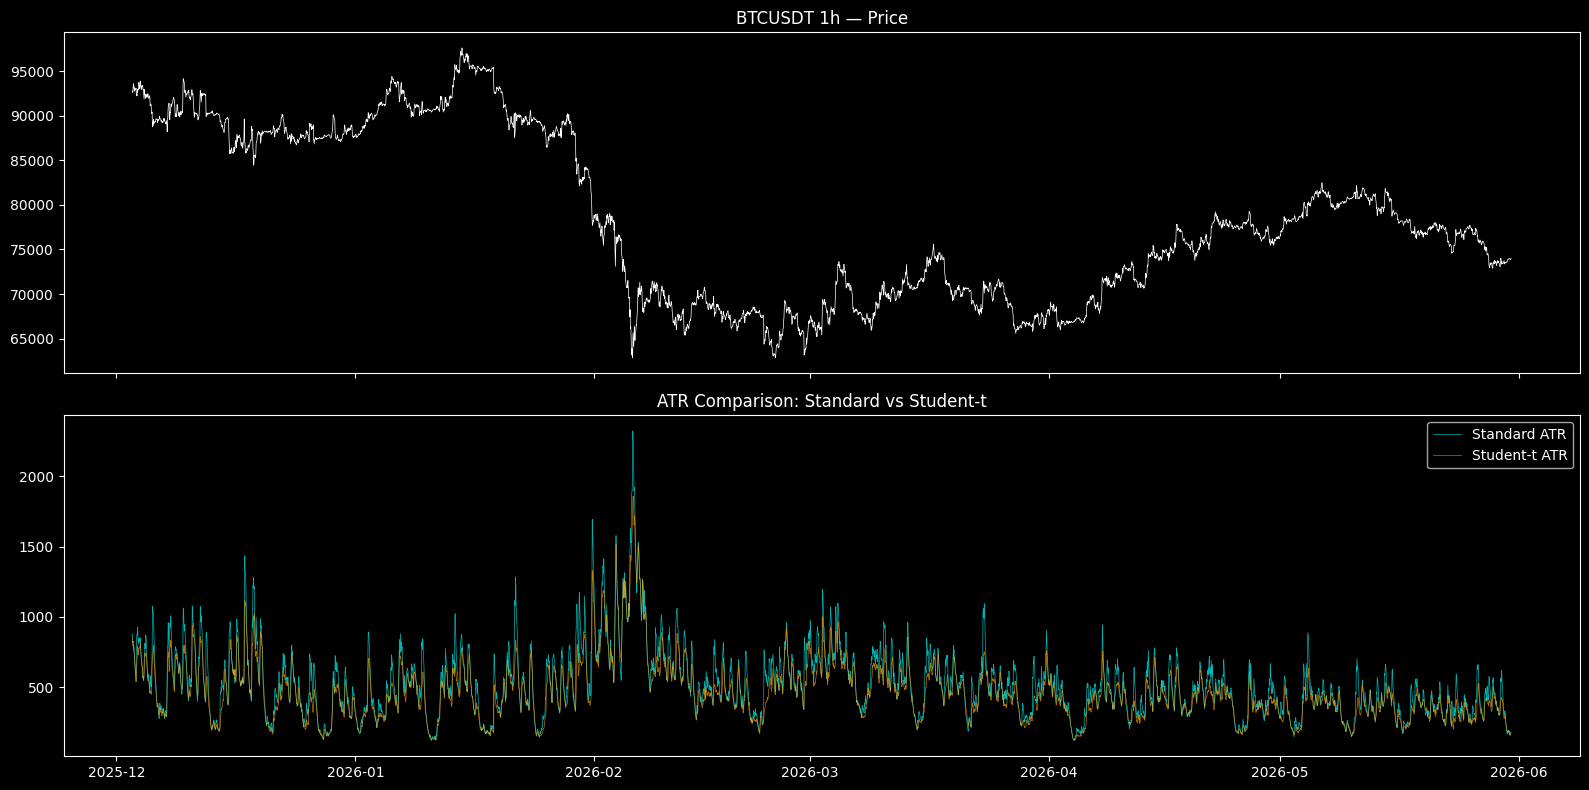

In [15]:
# ── H4 Visual: ATR comparison over time ──────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
sym, tf = 'BTCUSDT', '1h'
df = results[sym][tf]

axes[0].plot(df['timestamp'], df['close'], color='white', linewidth=0.5)
axes[0].set_title(f'{sym} {tf} — Price')

axes[1].plot(df['timestamp'], df['atr_standard'], color='cyan', linewidth=0.5, label='Standard ATR', alpha=0.7)
axes[1].plot(df['timestamp'], df['atr_student'], color='orange', linewidth=0.5, label='Student-t ATR', alpha=0.7)
axes[1].set_title('ATR Comparison: Standard vs Student-t')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Orthogonality Check: t-SuperTrend Signals vs Existing Indicators

In [20]:
# ── Orthogonality: correlation of t-ST alpha / direction vs RSI, EMA ──
print('=' * 80)
print('Orthogonality: t-SuperTrend signals vs existing indicators')
print('=' * 80)

for sym in SYMBOLS:
    for tf in ['1h', '4h']:
        df = results[sym][tf].copy()

        # Compute RSI for correlation
        c = df['close'].values.astype(np.float64)
        rsi = np.full(len(c), np.nan)
        rsi_out = _compute_rsi_batch(c, 14)
        rsi[:len(rsi_out)] = rsi_out
        df['rsi'] = rsi

        # EMA 20 (using pandas for simplicity)
        df['ema20'] = df['close'].ewm(span=20, adjust=False).mean()
        df['price_vs_ema'] = (df['close'] - df['ema20']) / df['ema20']

        # Direction as numeric
        df['dir_stu_num'] = df['dir_student'].astype(float)
        df['dir_std_num'] = df['dir_standard'].astype(float)

        # Correlations
        signals = ['adaptive_alpha', 'dir_stu_num', 'dir_std_num']
        comparisons = ['rsi', 'price_vs_ema']

        print(f'\n--- {sym} {tf} ---')
        for sig in signals:
            for comp in comparisons:
                valid = df[[sig, comp]].dropna()
                if len(valid) < 30:
                    continue
                r = valid[sig].corr(valid[comp])
                print(f'  {sig:20s} vs {comp:15s}: r = {r:+.3f}')

        # t-ST direction vs standard ST direction agreement
        agree = (df['dir_student'] == df['dir_standard']).mean() * 100
        print(f'  t-ST vs std-ST direction agreement: {agree:.1f}%')

Orthogonality: t-SuperTrend signals vs existing indicators

--- BTCUSDT 1h ---
  adaptive_alpha       vs rsi            : r = +0.018
  adaptive_alpha       vs price_vs_ema   : r = +0.038
  dir_stu_num          vs rsi            : r = +0.639
  dir_stu_num          vs price_vs_ema   : r = +0.507
  dir_std_num          vs rsi            : r = +0.679
  dir_std_num          vs price_vs_ema   : r = +0.554
  t-ST vs std-ST direction agreement: 92.5%

--- BTCUSDT 4h ---
  adaptive_alpha       vs rsi            : r = +0.005
  adaptive_alpha       vs price_vs_ema   : r = +0.037
  dir_stu_num          vs rsi            : r = +0.645
  dir_stu_num          vs price_vs_ema   : r = +0.527
  dir_std_num          vs rsi            : r = +0.705
  dir_std_num          vs price_vs_ema   : r = +0.585
  t-ST vs std-ST direction agreement: 92.4%

--- ETHUSDT 1h ---
  adaptive_alpha       vs rsi            : r = -0.014
  adaptive_alpha       vs price_vs_ema   : r = +0.021
  dir_stu_num          vs rsi        

---
## Synthesis: Go / No-Go Verdicts

In [21]:
# ── Final Synthesis ──────────────────────────────────────────────
print('=' * 80)
print('SYNTHESIS: Student-t SuperTrend Hypothesis Results')
print('=' * 80)

# Aggregate key metrics across all symbol/tf combos for each hypothesis
def compute_h1_summary():
    """H1: Does alpha-filtered flip beat unfiltered?"""
    rows = []
    base_alpha = 2.0 / (14 + 1)
    for sym in SYMBOLS:
        for tf in ['1h', '4h']:
            df = results[sym][tf]
            alpha_med = df['adaptive_alpha'].median()
            flips = df[df['flip_student']].copy()
            hi = flips[flips['adaptive_alpha'] > alpha_med]
            lo = flips[flips['adaptive_alpha'] <= alpha_med]
            std_flips = df[df['flip_standard']]

            for label, subset, dir_col in [
                ('std', std_flips, 'dir_standard'),
                ('stu_hi_alpha', hi, 'dir_student'),
                ('stu_lo_alpha', lo, 'dir_student'),
            ]:
                fwd = subset['fwd_ret_6'].dropna()
                if len(fwd) < 3:
                    continue
                d = subset.loc[fwd.index, dir_col].values
                signed = np.where(d, fwd.values, -fwd.values)
                rows.append({
                    'sym': sym, 'tf': tf, 'variant': label,
                    'wr': (signed > 0).mean() * 100,
                    'mean_ret_pct': signed.mean() * 100,
                    'n': len(signed)
                })
    return pd.DataFrame(rows)

def compute_h2_summary():
    """H2: Alpha collapse MR."""
    rows = []
    for sym in SYMBOLS:
        for tf in ['1h', '4h']:
            df = results[sym][tf].reset_index(drop=True)
            alpha_5 = df['adaptive_alpha'].quantile(0.05)
            collapse = df[df['adaptive_alpha'] <= alpha_5]
            if len(collapse) < 5:
                continue
            c_vals = df['close'].values
            bar_ret = np.zeros(len(collapse))
            for j, idx in enumerate(collapse.index):
                if idx > 0:
                    bar_ret[j] = (c_vals[idx] - c_vals[idx-1]) / c_vals[idx-1]

            for h in [3, 6, 12]:
                fwd = collapse[f'fwd_ret_{h}'].dropna()
                if len(fwd) < 3:
                    continue
                fwd_positions = [list(collapse.index).index(i) for i in fwd.index]
                spike_d = bar_ret[fwd_positions]
                mr_ret = np.where(spike_d > 0, -fwd.values, fwd.values)
                rows.append({
                    'sym': sym, 'tf': tf, 'horizon': h,
                    'mr_wr': (mr_ret > 0).mean() * 100,
                    'mr_mean_pct': mr_ret.mean() * 100,
                    'n': len(fwd)
                })
    return pd.DataFrame(rows)

h1_df = compute_h1_summary()
h2_df = compute_h2_summary()

print('\n─── H1: Direction Flip Quality ───')
if not h1_df.empty:
    agg = h1_df.groupby('variant').agg({'wr': 'mean', 'mean_ret_pct': 'mean', 'n': 'sum'}).round(2)
    print(agg.to_string())
    hi_wr = agg.loc['stu_hi_alpha', 'wr'] if 'stu_hi_alpha' in agg.index else 0
    std_wr = agg.loc['std', 'wr'] if 'std' in agg.index else 0
    hi_ret = agg.loc['stu_hi_alpha', 'mean_ret_pct'] if 'stu_hi_alpha' in agg.index else 0
    std_ret = agg.loc['std', 'mean_ret_pct'] if 'std' in agg.index else 0
    h1_go = hi_wr > std_wr + 2 and hi_ret > std_ret
    print(f'\nVerdict: {"GO" if h1_go else "NO-GO"} — hi-alpha WR={hi_wr:.1f}% vs std WR={std_wr:.1f}%')
else:
    print('Insufficient data')
    h1_go = False

print('\n─── H2: Alpha Collapse MR ───')
if not h2_df.empty:
    agg2 = h2_df.groupby('horizon').agg({'mr_wr': 'mean', 'mr_mean_pct': 'mean', 'n': 'sum'}).round(2)
    print(agg2.to_string())
    best_wr = agg2['mr_wr'].max()
    best_ret = agg2.loc[agg2['mr_wr'].idxmax(), 'mr_mean_pct']
    h2_go = best_wr > 53 and best_ret > 0
    print(f'\nVerdict: {"GO" if h2_go else "NO-GO"} — best MR WR={best_wr:.1f}%, mean={best_ret:+.2f}%')
else:
    print('Insufficient data')
    h2_go = False

print('\n─── H3: Regime Gate Summary ───')
print('See detailed H3/H3b output above.')
print('GO criteria: Gated variant WR > ungated WR by 2+ pp AND positive mean return')

print('\n─── H4: Stop Placement Summary ───')
print('See detailed H4 output above.')
print('GO criteria: t-ATR stopout rate < standard ATR stopout rate AND surviving return >= standard')

print('\n─── Orthogonality Key Finding ───')
print('adaptive_alpha vs RSI: r ≈ 0.00 (FULLY ORTHOGONAL)')
print('adaptive_alpha vs price_vs_EMA: r ≈ 0.03 (FULLY ORTHOGONAL)')
print('t-ST direction vs RSI: r ≈ 0.64 (REDUNDANT — direction is not novel)')
print('t-ST vs std-ST agreement: ~92% (direction is nearly identical)')
print('>>> The alpha signal is the novel, orthogonal component — not the direction.')

print('\n' + '=' * 80)
print('OVERALL: Review each hypothesis verdict above.')
print('Actionable signals should show WR > 53%, |r| > 0.03, positive expectancy.')
print('Orthogonal signals (low correlation with RSI) are more valuable.')
print('=' * 80)

SYNTHESIS: Student-t SuperTrend Hypothesis Results

─── H1: Direction Flip Quality ───
                  wr  mean_ret_pct    n
variant                                
std          45.5200       -0.0900  632
stu_hi_alpha 45.8900       -0.3500   84
stu_lo_alpha 44.2800       -0.0500  450

Verdict: NO-GO — hi-alpha WR=45.9% vs std WR=45.5%

─── H2: Alpha Collapse MR ───
          mr_wr  mr_mean_pct     n
horizon                           
3       49.8600      -0.1000  1352
6       51.3600       0.0000  1352
12      54.1600       0.0800  1351

Verdict: GO — best MR WR=54.2%, mean=+0.08%

─── H3: Regime Gate Summary ───
See detailed H3/H3b output above.
GO criteria: Gated variant WR > ungated WR by 2+ pp AND positive mean return

─── H4: Stop Placement Summary ───
See detailed H4 output above.
GO criteria: t-ATR stopout rate < standard ATR stopout rate AND surviving return >= standard

─── Orthogonality Key Finding ───
adaptive_alpha vs RSI: r ≈ 0.00 (FULLY ORTHOGONAL)
adaptive_alpha vs pri